# Visualizações Estatísticas com Seaborn

Neste notebook, vamos explorar as capacidades estatísticas do Seaborn para análise exploratória de dados:
- Distribuições
- Regressões
- Análise de variância
- Visualizações de resíduos

In [1]:
# Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurando o estilo do Seaborn
sns.set_theme()

# Configurando o tamanho padrão das figuras
plt.rcParams['figure.figsize'] = [10, 6]

## 1. Análise de Distribuições

Vamos explorar diferentes formas de visualizar distribuições de dados.

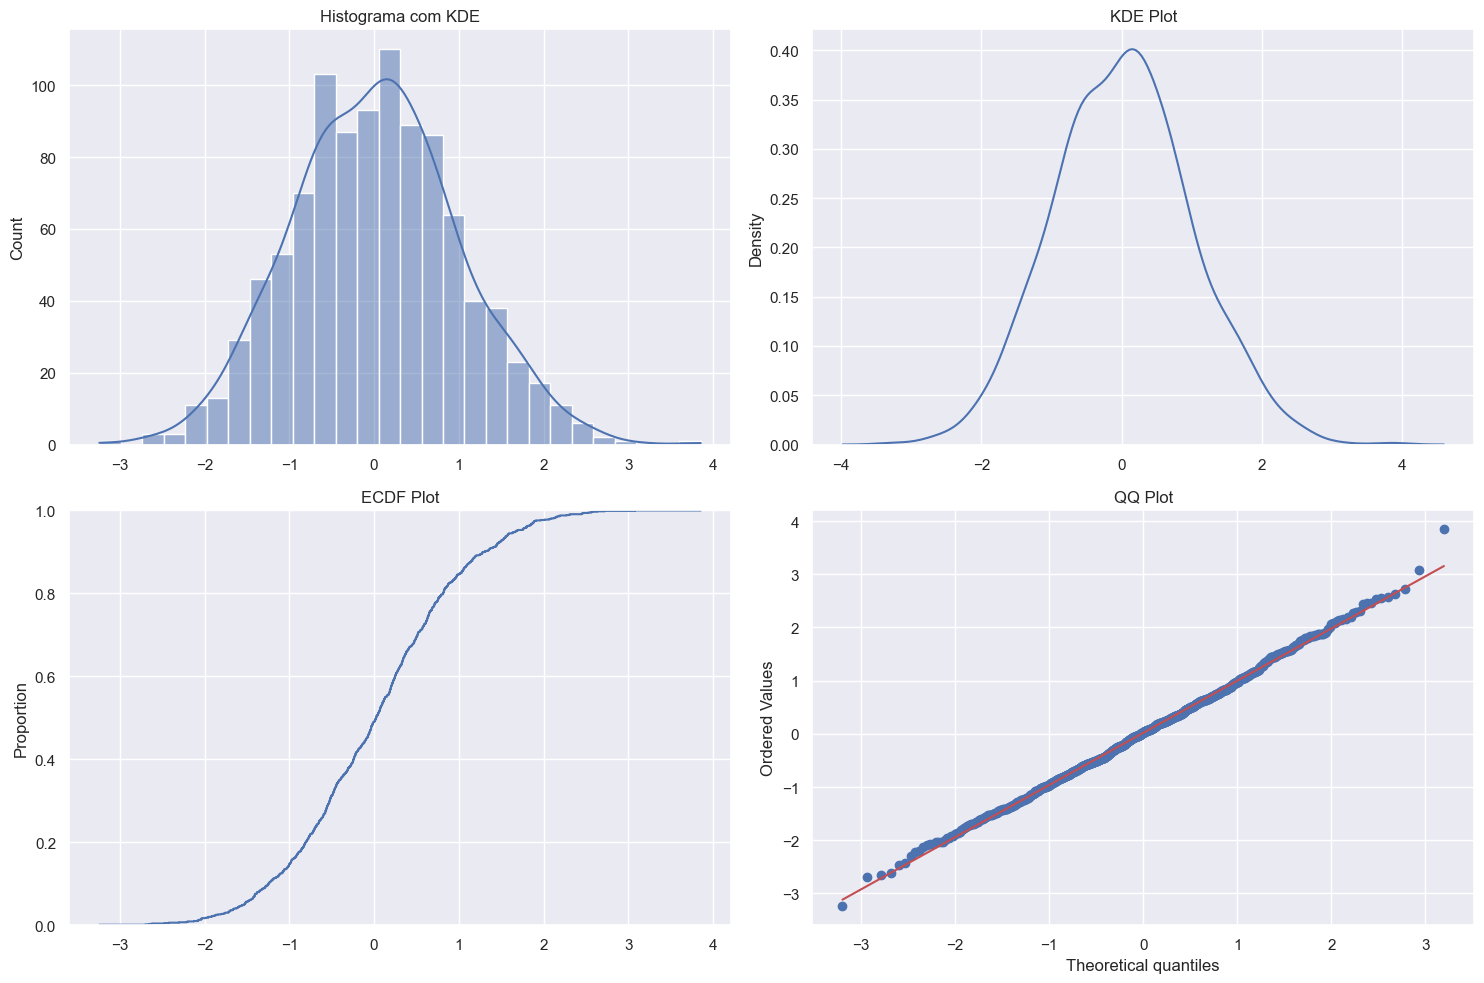

In [2]:
# Criando dados de exemplo
np.random.seed(42)
dados = np.random.normal(0, 1, 1000)

# Criando uma figura com múltiplos gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histograma com KDE
sns.histplot(data=dados, kde=True, ax=axes[0,0])
axes[0,0].set_title('Histograma com KDE')

# KDE plot
sns.kdeplot(data=dados, ax=axes[0,1])
axes[0,1].set_title('KDE Plot')

# ECDF plot
sns.ecdfplot(data=dados, ax=axes[1,0])
axes[1,0].set_title('ECDF Plot')

# QQ plot
stats.probplot(dados, dist='norm', plot=axes[1,1])
axes[1,1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

## 2. Análise de Regressão

Vamos explorar diferentes tipos de regressão e suas visualizações.

RuntimeError: `robust=True` requires statsmodels, an optional dependency, to be installed.

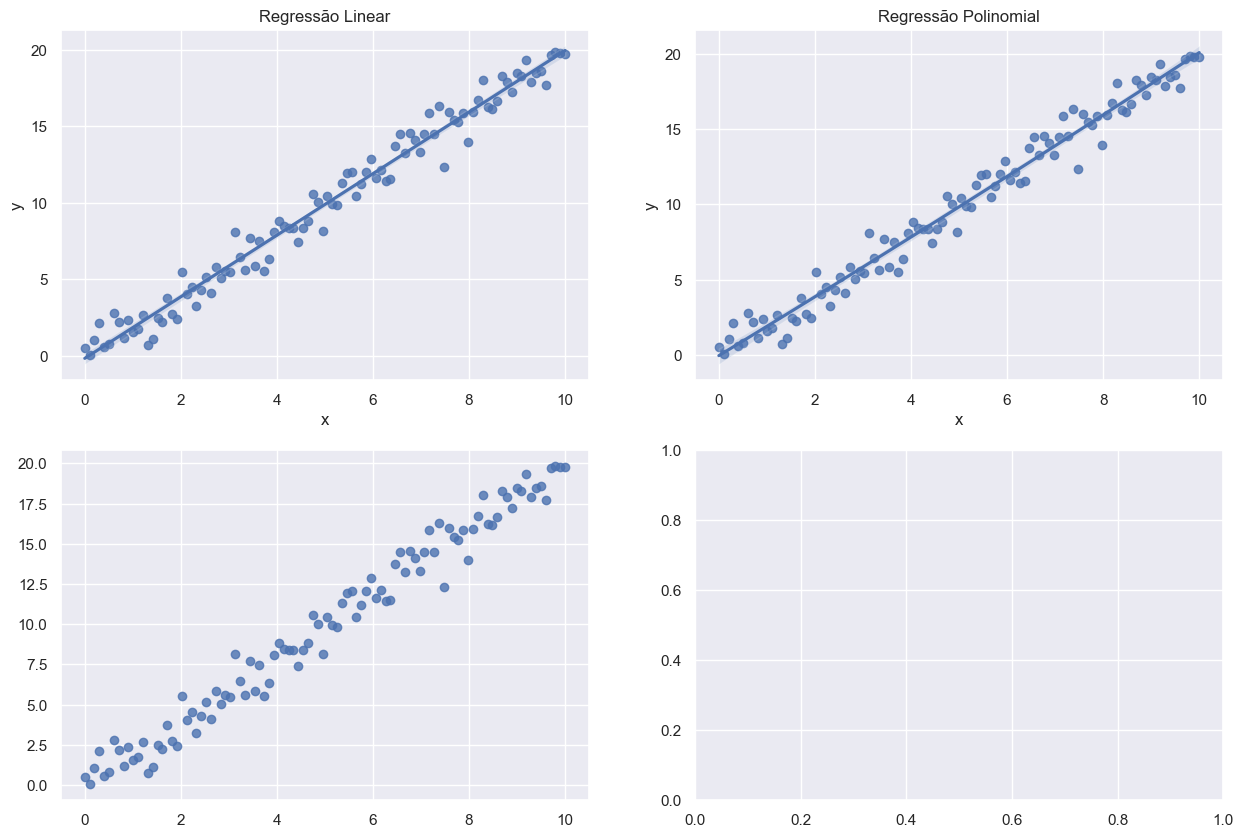

In [3]:
# Criando dados de exemplo
np.random.seed(42)
x = np.linspace(0, 10, 100)
y = 2 * x + np.random.normal(0, 1, 100)

# Criando um DataFrame
df = pd.DataFrame({'x': x, 'y': y})

# Criando uma figura com múltiplos gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Regressão linear
sns.regplot(data=df, x='x', y='y', ax=axes[0,0])
axes[0,0].set_title('Regressão Linear')

# Regressão polinomial
sns.regplot(data=df, x='x', y='y', order=2, ax=axes[0,1])
axes[0,1].set_title('Regressão Polinomial')

# Regressão robusta
sns.regplot(data=df, x='x', y='y', robust=True, ax=axes[1,0])
axes[1,0].set_title('Regressão Robusta')

# Regressão com intervalo de confiança
sns.regplot(data=df, x='x', y='y', ci=95, ax=axes[1,1])
axes[1,1].set_title('Regressão com IC 95%')

plt.tight_layout()
plt.show()

## 3. Análise de Variância

Vamos explorar visualizações para análise de variância.

In [ ]:
# Criando dados de exemplo
np.random.seed(42)
df = pd.DataFrame({
    'valor': np.concatenate([
        np.random.normal(0, 1, 100),
        np.random.normal(2, 1, 100),
        np.random.normal(-2, 1, 100)
    ]),
    'grupo': ['A'] * 100 + ['B'] * 100 + ['C'] * 100
})

# Criando uma figura com múltiplos gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Boxplot
sns.boxplot(data=df, x='grupo', y='valor', ax=axes[0,0])
axes[0,0].set_title('Boxplot')

# Violinplot
sns.violinplot(data=df, x='grupo', y='valor', ax=axes[0,1])
axes[0,1].set_title('Violinplot')

# Swarmplot
sns.swarmplot(data=df, x='grupo', y='valor', ax=axes[1,0])
axes[1,0].set_title('Swarmplot')

# Boxenplot
sns.boxenplot(data=df, x='grupo', y='valor', ax=axes[1,1])
axes[1,1].set_title('Boxenplot')

plt.tight_layout()
plt.show()

## 4. Análise de Resíduos

Vamos explorar visualizações para análise de resíduos em modelos de regressão.

In [ ]:
# Criando dados de exemplo
np.random.seed(42)
x = np.linspace(0, 10, 100)
y = 2 * x + np.random.normal(0, 1, 100)

# Ajustando um modelo de regressão linear
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)
y_pred = model.predict(x.reshape(-1, 1))
residuos = y - y_pred

# Criando um DataFrame
df = pd.DataFrame({
    'x': x,
    'y': y,
    'y_pred': y_pred,
    'residuos': residuos
})

# Criando uma figura com múltiplos gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico de dispersão com linha de regressão
sns.regplot(data=df, x='x', y='y', ax=axes[0,0])
axes[0,0].set_title('Dados e Regressão')

# Gráfico de resíduos vs valores preditos
sns.scatterplot(data=df, x='y_pred', y='residuos', ax=axes[0,1])
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_title('Resíduos vs Valores Preditos')

# Histograma dos resíduos
sns.histplot(data=df, x='residuos', kde=True, ax=axes[1,0])
axes[1,0].set_title('Distribuição dos Resíduos')

# QQ plot dos resíduos
stats.probplot(df['residuos'], dist='norm', plot=axes[1,1])
axes[1,1].set_title('QQ Plot dos Resíduos')

plt.tight_layout()
plt.show()